In [2]:
import pandas as pd

import geopandas as gpd
import matplotlib.pyplot as plt


🔍 UNIQUE RAW STATES:
Andaman & Nicobar Islands
Andaman and Nicobar Islands
Andhra Pradesh
Arunachal Pradesh
Assam
Bihar
Chandigarh
Chhatisgarh
Chhattisgarh
Dadra & Nagar Haveli
Dadra and Nagar Haveli
Dadra and Nagar Haveli and Daman and Diu
Daman & Diu
Daman and Diu
Delhi
Goa
Gujarat
Haryana
Himachal Pradesh
Jammu & Kashmir
Jammu and Kashmir
Jharkhand
Karnataka
Kerala
Ladakh
Lakshadweep
Madhya Pradesh
Maharashtra
Manipur
Meghalaya
Mizoram
Nagaland
ODISHA
Odisha
Orissa
Pondicherry
Puducherry
Punjab
Rajasthan
Sikkim
Tamil Nadu
Tamilnadu
Telangana
Tripura
Uttar Pradesh
Uttarakhand
Uttaranchal
WEST BENGAL
WESTBENGAL
West  Bengal
West Bangal
West Bengal
West bengal
Westbengal
andhra pradesh
odisha
west Bengal

✅ STATES AFTER FIRST PASS:
Andaman And Nicobar Islands
Andhra Pradesh
Arunachal Pradesh
Assam
Bihar
Chandigarh
Chhattisgarh
Dadra And Nagar Haveli And Daman And Diu
Delhi
Goa
Gujarat
Haryana
Himachal Pradesh
Jammu And Kashmir
Jharkhand
Karnataka
Kerala
Ladakh
Lakshadweep
Madhya Prade

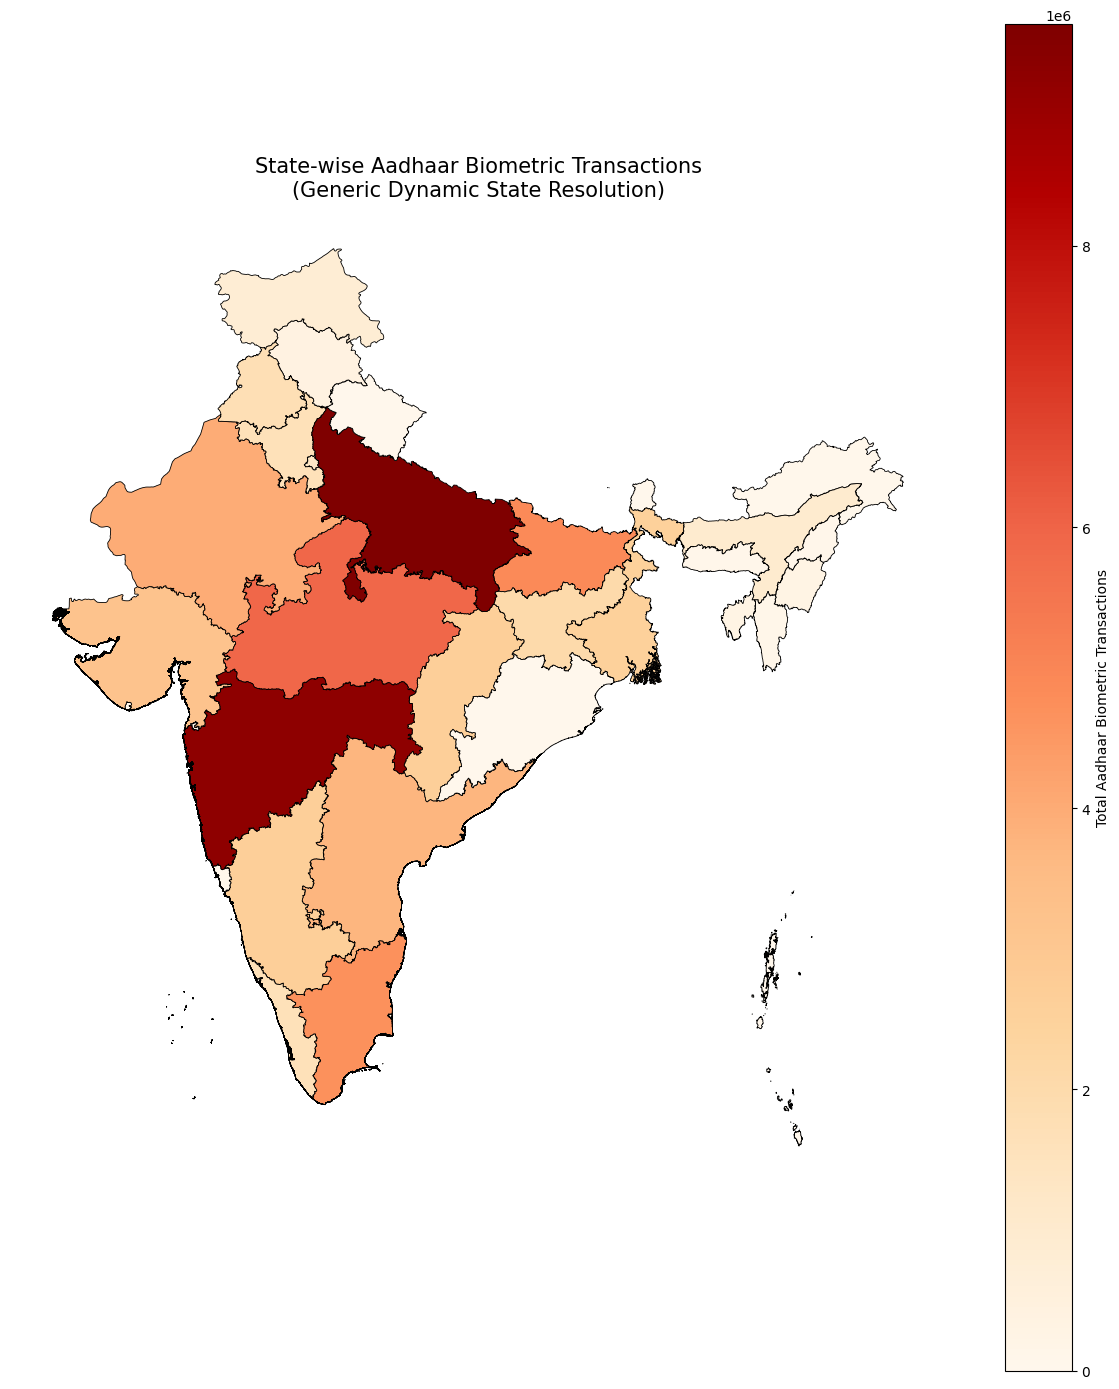


🗺️ Choropleth map generated successfully


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import re
import json
from rapidfuzz import process, fuzz

# =====================================
# CONFIG
# =====================================
CSV_FILES = [
    "api_1.csv",
    "api_2.csv",
    "api_3.csv",
    "api_4.csv"
]

GEOJSON_PATH = "india_states.geojson"  # or .txt

# =====================================
# CANONICAL STATE REGISTRY
# =====================================
CANONICAL_STATES = [
    "Andaman And Nicobar Islands", "Andhra Pradesh", "Arunachal Pradesh",
    "Assam", "Bihar", "Chandigarh", "Chhattisgarh",
    "Dadra And Nagar Haveli And Daman And Diu", "Delhi", "Goa",
    "Gujarat", "Haryana", "Himachal Pradesh", "Jammu And Kashmir",
    "Jharkhand", "Karnataka", "Kerala", "Ladakh", "Lakshadweep",
    "Madhya Pradesh", "Maharashtra", "Manipur", "Meghalaya",
    "Mizoram", "Nagaland", "Odisha", "Puducherry", "Punjab",
    "Rajasthan", "Sikkim", "Tamil Nadu", "Telangana", "Tripura",
    "Uttar Pradesh", "Uttarakhand", "West Bengal"
]

# =====================================
# NORMALIZATION
# =====================================
def normalize_text(s):
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = re.sub(r"[^a-z\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

# Pre-normalize canonical states ONCE
CANONICAL_NORM = {normalize_text(s): s for s in CANONICAL_STATES}
CANONICAL_KEYS = list(CANONICAL_NORM.keys())

# =====================================
# FAST FIRST-PASS RESOLVER (FUZZY + CACHE)
# =====================================
RESOLUTION_CACHE = {}

def resolve_state_fast(raw_state, threshold=80):
    if raw_state in RESOLUTION_CACHE:
        return RESOLUTION_CACHE[raw_state]

    cleaned = normalize_text(raw_state)
    if not cleaned:
        RESOLUTION_CACHE[raw_state] = None
        return None

    # Exact normalized match
    if cleaned in CANONICAL_NORM:
        RESOLUTION_CACHE[raw_state] = CANONICAL_NORM[cleaned]
        return CANONICAL_NORM[cleaned]

    # Fuzzy match
    match, score, _ = process.extractOne(
        cleaned, CANONICAL_KEYS, scorer=fuzz.token_sort_ratio
    )

    if score >= threshold:
        resolved = CANONICAL_NORM[match]
        RESOLUTION_CACHE[raw_state] = resolved
        return resolved

    RESOLUTION_CACHE[raw_state] = None
    return None

# =====================================
# GENERIC SECOND-PASS RESOLVER (NO HACKS)
# =====================================
def resolve_state_second_pass(raw_state, min_score=2):
    """
    Generic resolver using token overlap + substring evidence
    """
    if pd.isna(raw_state):
        return None

    cleaned = normalize_text(raw_state)
    if not cleaned:
        return None

    raw_tokens = set(cleaned.split())

    best_state = None
    best_score = 0

    for state in CANONICAL_STATES:
        st_norm = normalize_text(state)
        st_tokens = set(st_norm.split())

        token_overlap = len(raw_tokens & st_tokens)
        substr_overlap = sum(
            1 for t in raw_tokens if len(t) >= 3 and t in st_norm
        )

        score = token_overlap + substr_overlap

        if score > best_score:
            best_score = score
            best_state = state

    if best_score >= min_score:
        return best_state

    return None

# =====================================
# STEP 1: LOAD ALL CSVs
# =====================================
df_all = pd.concat(
    (pd.read_csv(f) for f in CSV_FILES),
    ignore_index=True
)

# Preserve raw state
df_all["state_raw"] = df_all["state"]

# =====================================
# PRINT RAW STATES
# =====================================
print("\n🔍 UNIQUE RAW STATES:")
for s in sorted(df_all["state_raw"].dropna().unique()):
    print(s)

# =====================================
# STEP 2: FIRST-PASS RESOLUTION (UNIQUE ONLY)
# =====================================
unique_states = df_all["state_raw"].dropna().unique()
state_map = {s: resolve_state_fast(s) for s in unique_states}

df_all["state"] = df_all["state_raw"].map(state_map)

# =====================================
# PRINT AFTER FIRST PASS
# =====================================
print("\n✅ STATES AFTER FIRST PASS:")
for s in sorted(df_all["state"].dropna().unique()):
    print(s)

# =====================================
# STEP 3: SECOND-PASS GENERIC RESOLUTION
# =====================================
unresolved_mask = df_all["state"].isna()

if unresolved_mask.any():
    print("\n🔧 Running generic second-pass resolution...")

    fixed = 0
    for idx in df_all[unresolved_mask].index:
        raw_val = df_all.at[idx, "state_raw"]
        resolved = resolve_state_second_pass(raw_val)
        if resolved:
            df_all.at[idx, "state"] = resolved
            fixed += 1

    print(f"✅ Second-pass fixed {fixed} rows")

# =====================================
# PRINT FINAL STATES
# =====================================
print("\n📊 FINAL RESOLVED STATES:")
for s in sorted(df_all["state"].dropna().unique()):
    print(s)

# =====================================
# STEP 4: BIOMETRIC PROCESSING
# =====================================
bio_cols = [c for c in df_all.columns if c.startswith("bio_age_")]

df_all[bio_cols] = (
    df_all[bio_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
)

df_all["total_biometrics"] = df_all[bio_cols].sum(axis=1)

# =====================================
# STEP 5: AGGREGATE STATE-WISE
# =====================================
state_totals = (
    df_all
    .dropna(subset=["state"])
    .groupby("state", as_index=False)["total_biometrics"]
    .sum()
)

state_totals.to_csv("clean_statewise_biometrics.csv", index=False)

# =====================================
# STEP 6: LOAD GEOJSON
# =====================================
try:
    india_map = gpd.read_file(GEOJSON_PATH)
except:
    with open(GEOJSON_PATH, "r", encoding="utf-8") as f:
        india_map = gpd.GeoDataFrame.from_features(json.load(f)["features"])

india_map = india_map.rename(columns={
    "st_nm": "state",
    "STATE_NAME": "state",
    "NAME_1": "state"
})

india_map["state"] = india_map["state"].apply(resolve_state_final)


# =====================================
# STEP 7: CHOROPLETH
# =====================================
merged = india_map.merge(state_totals, on="state", how="left")
merged["total_biometrics"] = merged["total_biometrics"].fillna(0)

fig, ax = plt.subplots(figsize=(12, 14))

merged.plot(
    column="total_biometrics",
    cmap="OrRd",
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    ax=ax,
    legend_kwds={"label": "Total Aadhaar Biometric Transactions"}
)

ax.set_title(
    "State-wise Aadhaar Biometric Transactions\n(Generic Dynamic State Resolution)",
    fontsize=15
)

ax.axis("off")
plt.tight_layout()
plt.show()

print("\n🗺️ Choropleth map generated successfully")


In [8]:
import pandas as pd
import numpy as np

# ================================
# LOAD CLEAN DATA
# ================================
df = pd.read_csv("clean_statewise_biometrics.csv")

print("\n📊 INFERENCE REPORT: Aadhaar Biometric Usage\n")

# ================================
# BASIC STATS
# ================================
total_usage = df["total_biometrics"].sum()
mean_usage = df["total_biometrics"].mean()
median_usage = df["total_biometrics"].median()
std_dev = df["total_biometrics"].std()

print("1️⃣ Overall Statistics")
print(f"- Total biometric transactions: {total_usage:,.0f}")
print(f"- Average per state: {mean_usage:,.0f}")
print(f"- Median per state: {median_usage:,.0f}")
print(f"- Std deviation: {std_dev:,.0f}\n")

# ================================
# TOP & BOTTOM STATES
# ================================
top_5 = df.sort_values("total_biometrics", ascending=False).head(5)
bottom_5 = df.sort_values("total_biometrics").head(5)

print("2️⃣ Highest Usage States")
for i, row in top_5.iterrows():
    print(f"- {row['state']}: {row['total_biometrics']:,.0f}")

print("\n3️⃣ Lowest Usage States")
for i, row in bottom_5.iterrows():
    print(f"- {row['state']}: {row['total_biometrics']:,.0f}")

# ================================
# OUTLIER DETECTION (Z-SCORE)
# ================================
df["z_score"] = (df["total_biometrics"] - mean_usage) / std_dev

high_outliers = df[df["z_score"] > 1.5]
low_outliers = df[df["z_score"] < -1.5]

print("\n4️⃣ Usage Outliers")

if not high_outliers.empty:
    print("- Exceptionally HIGH usage states:")
    for _, row in high_outliers.iterrows():
        print(f"  • {row['state']} (z={row['z_score']:.2f})")
else:
    print("- No extreme high-usage outliers detected")

if not low_outliers.empty:
    print("- Exceptionally LOW usage states:")
    for _, row in low_outliers.iterrows():
        print(f"  • {row['state']} (z={row['z_score']:.2f})")
else:
    print("- No extreme low-usage outliers detected")

# ================================
# INEQUALITY MEASURE (GINI)
# ================================
def gini(array):
    array = np.sort(array)
    n = len(array)
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))

gini_coeff = gini(df["total_biometrics"].values)

print("\n5️⃣ Usage Inequality")
print(f"- Gini coefficient: {gini_coeff:.2f}")

if gini_coeff > 0.45:
    print("- Aadhaar biometric usage is highly concentrated in a few states")
elif gini_coeff > 0.30:
    print("- Aadhaar biometric usage shows moderate inequality")
else:
    print("- Aadhaar biometric usage is fairly evenly distributed")

# ================================
# AUTOMATED CONCLUSIONS
# ================================
print("\n6️⃣ Auto-Generated Conclusions")

if top_5.iloc[0]["total_biometrics"] > 2 * mean_usage:
    print("- A small number of states dominate Aadhaar biometric usage")

if median_usage < mean_usage:
    print("- Usage distribution is right-skewed (few high-usage states)")

if len(high_outliers) >= 3:
    print("- High-usage cluster indicates stronger Aadhaar service integration")

print("\n✅ Inference generation complete.\n")



📊 INFERENCE REPORT: Aadhaar Biometric Usage

1️⃣ Overall Statistics
- Total biometric transactions: 69,763,095
- Average per state: 1,316,285
- Median per state: 87,626
- Std deviation: 2,202,433

2️⃣ Highest Usage States
- Uttar Pradesh: 9,577,735
- Maharashtra: 9,226,139
- Madhya Pradesh: 5,923,771
- Bihar: 4,897,587
- Tamil Nadu: 4,698,117

3️⃣ Lowest Usage States
- west Bengal: 1
- Tamilnadu: 1
- Uttaranchal: 2
- Chhatisgarh: 5
- WESTBENGAL: 12

4️⃣ Usage Outliers
- Exceptionally HIGH usage states:
  • Bihar (z=1.63)
  • Madhya Pradesh (z=2.09)
  • Maharashtra (z=3.59)
  • Tamil Nadu (z=1.54)
  • Uttar Pradesh (z=3.75)
- No extreme low-usage outliers detected

5️⃣ Usage Inequality
- Gini coefficient: 0.74
- Aadhaar biometric usage is highly concentrated in a few states

6️⃣ Auto-Generated Conclusions
- A small number of states dominate Aadhaar biometric usage
- Usage distribution is right-skewed (few high-usage states)
- High-usage cluster indicates stronger Aadhaar service integr